In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv("csvs/final_defesas2006.csv", index_col=0)
data.head()

,tipo,url,orientador,avaliador1,avaliador2,avaliador3,avaliador4,avaliador5,avaliador6,orientador_filiação,...,avaliador1_keyword_5,avaliador2_keyword_5,avaliador3_keyword_1,avaliador3_keyword_2,avaliador3_keyword_3,avaliador4_keyword_1,avaliador4_keyword_2,avaliador4_keyword_3,avaliador4_keyword_4,avaliador4_keyword_5
0,MESTRADO,https://repositorio.unicamp.br/acervo/detalhe/...,orcid.org/0000-0002-6540-8686,sem orcid,orcid.org/0000-0002-8803-0401,NaN,NaN,NaN,NaN,University of Campinas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MESTRADO,https://repositorio.unicamp.br/acervo/detalhe/...,orcid.org/0000-0002-6540-8686,sem orcid,orcid.org/0000-0002-7002-875X,NaN,NaN,NaN,NaN,University of Campinas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MESTRADO,https://repositorio.unicamp.br/acervo/detalhe/...,orcid.org/0000-0003-4869-5190,orcid.org/0000-0002-8803-0401,orcid.org/0000-0003-1574-0362,NaN,NaN,NaN,NaN,Universidade Estadual de Campinas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MESTRADO,https://repositorio.unicamp.br/acervo/detalhe/...,orcid.org/0000-0001-5685-8004,sem orcid,orcid.org/0000-0002-7002-875X,NaN,NaN,NaN,NaN,no info,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MESTRADO,https://repositorio.unicamp.br/acervo/detalhe/...,orcid.org/0000-0001-5685-8004,orcid.org/0000-0001-5489-4909,orcid.org/0000-0002-9554-1381,orcid.org/0000-0002-3159-4839,NaN,NaN,NaN,no info,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
data["orientador_nome"].value_counts()

orientador_nome
sem orcid                             14
Eliane Martins                         6
Ricardo Dahab                          5
Maria Cecilia Calani Baranauskas       5
Nelson L. S. da Fonseca                5
Paulo de Geus                          4
Cecilia Mary Fischer Rubira Rubira     4
Edmundo Madeira                        4
Flávio K. Miyazawa                     3
Guido Araujo                           2
Zanoni Dias                            2
Jacques Wainer                         2
Siome Goldenstein                      2
Ricardo Anido                          2
Islene Calciolari Garcia               2
Claudia Medeiros                       2
Mario Jino                             2
Alexandre Falcao                       1
Cid de Souza                           1
mario cortes                           1
Luiz Eduardo Buzato                    1
Rodolfo Azevedo                        1
Name: count, dtype: int64

In [211]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas = nx.DiGraph()
n_banca = 0
for col in data.columns[2:]:
    if "_" in col: continue
    # if "orientador" not in "col"
    for index, url in enumerate(data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        grafo_defesas.add_node(url.split("/")[-1], nome=data.at[index, f"{col}_nome"], filiacao=data.at[index, f"{col}_filiação"], orcid=url.split("/")[-1])
    n_banca -=- 1

In [212]:
grafo_defesas.has_edge('0000-0002-6540-8686', '0000-0002-8803-0401')

False

In [ ]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas.has_edge(orcid_orient, orcid_aval):
            grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
            continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1)
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
for p1, p2 in grafo_defesas.edges:
    edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [214]:
grafo_defesas.has_edge('0000-0002-6540-8686', '0000-0002-8803-0401')

True

In [215]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

In [216]:
print(f"Pessoa(s) com maior grau de entrada ({max_degree_in}):", end=" ")
for p in max_degree_person_in:
    print(grafo_defesas.nodes[p])

Pessoa(s) com maior grau de entrada (3): {'nome': 'Siome Goldenstein', 'filiacao': 'no info', 'orcid': '0000-0001-5685-8004'}
{'nome': 'Ricardo Anido', 'filiacao': 'University of Campinas', 'orcid': '0000-0002-8856-194X'}
{'nome': 'Edmundo Madeira', 'filiacao': 'UNICAMP - University of Campinas', 'orcid': '0000-0002-1180-2637'}
{'nome': 'Cecilia Mary Fischer Rubira Rubira', 'filiacao': 'no info', 'orcid': '0000-0003-4549-7105'}
{'nome': 'Eliane Martins', 'filiacao': 'no info', 'orcid': '0000-0003-4290-6508'}
{'nome': 'Ricardo Dahab', 'filiacao': 'University of Campinas', 'orcid': '0000-0002-7002-875X'}
{'nome': 'Luiz Eduardo Buzato', 'filiacao': 'University of Campinas', 'orcid': '0000-0002-3823-8941'}
{'nome': 'Rodolfo Azevedo', 'filiacao': 'UNICAMP', 'orcid': '0000-0002-8803-0401'}


In [217]:
print(f"Pessoa(s) com maior grau de saída ({max_degree_out}):", end=" ")
for p in max_degree_person_out:
    print(grafo_defesas.nodes[p])

Pessoa(s) com maior grau de saída (7): {'nome': 'Eliane Martins', 'filiacao': 'no info', 'orcid': '0000-0003-4290-6508'}


In [218]:
maior_n_contribs = 0
for node in grafo_defesas:
   for colab in grafo_defesas[node]:
      if grafo_defesas[node][colab]["qtd"] > maior_n_contribs:
         maior_n_contribs = grafo_defesas[node][colab]["qtd"]

maiores_contribs = []
for node in grafo_defesas:
   for colab in grafo_defesas[node]:
      if grafo_defesas[node][colab]["qtd"] == maior_n_contribs:
         maiores_contribs.append((grafo_defesas.nodes[node]['nome'], grafo_defesas.nodes[colab]['nome']))

In [226]:
edge_colors = []
for p1, p2 in grafo_defesas.edges:
    if (grafo_defesas.nodes[p1]['nome'], grafo_defesas.nodes[p2]['nome']) in maiores_contribs:
        edge_colors.append("red")
    else:
        edge_colors.append("k")

In [219]:
maior_n_contribs, maiores_contribs

(3,
 [('Nelson L. S. da Fonseca', 'Edmundo Madeira'),
  ('Cecilia Mary Fischer Rubira Rubira', 'Eliane Martins'),
  ('Ricardo Dahab', 'Julio Cesar Lopez Hernandez')])

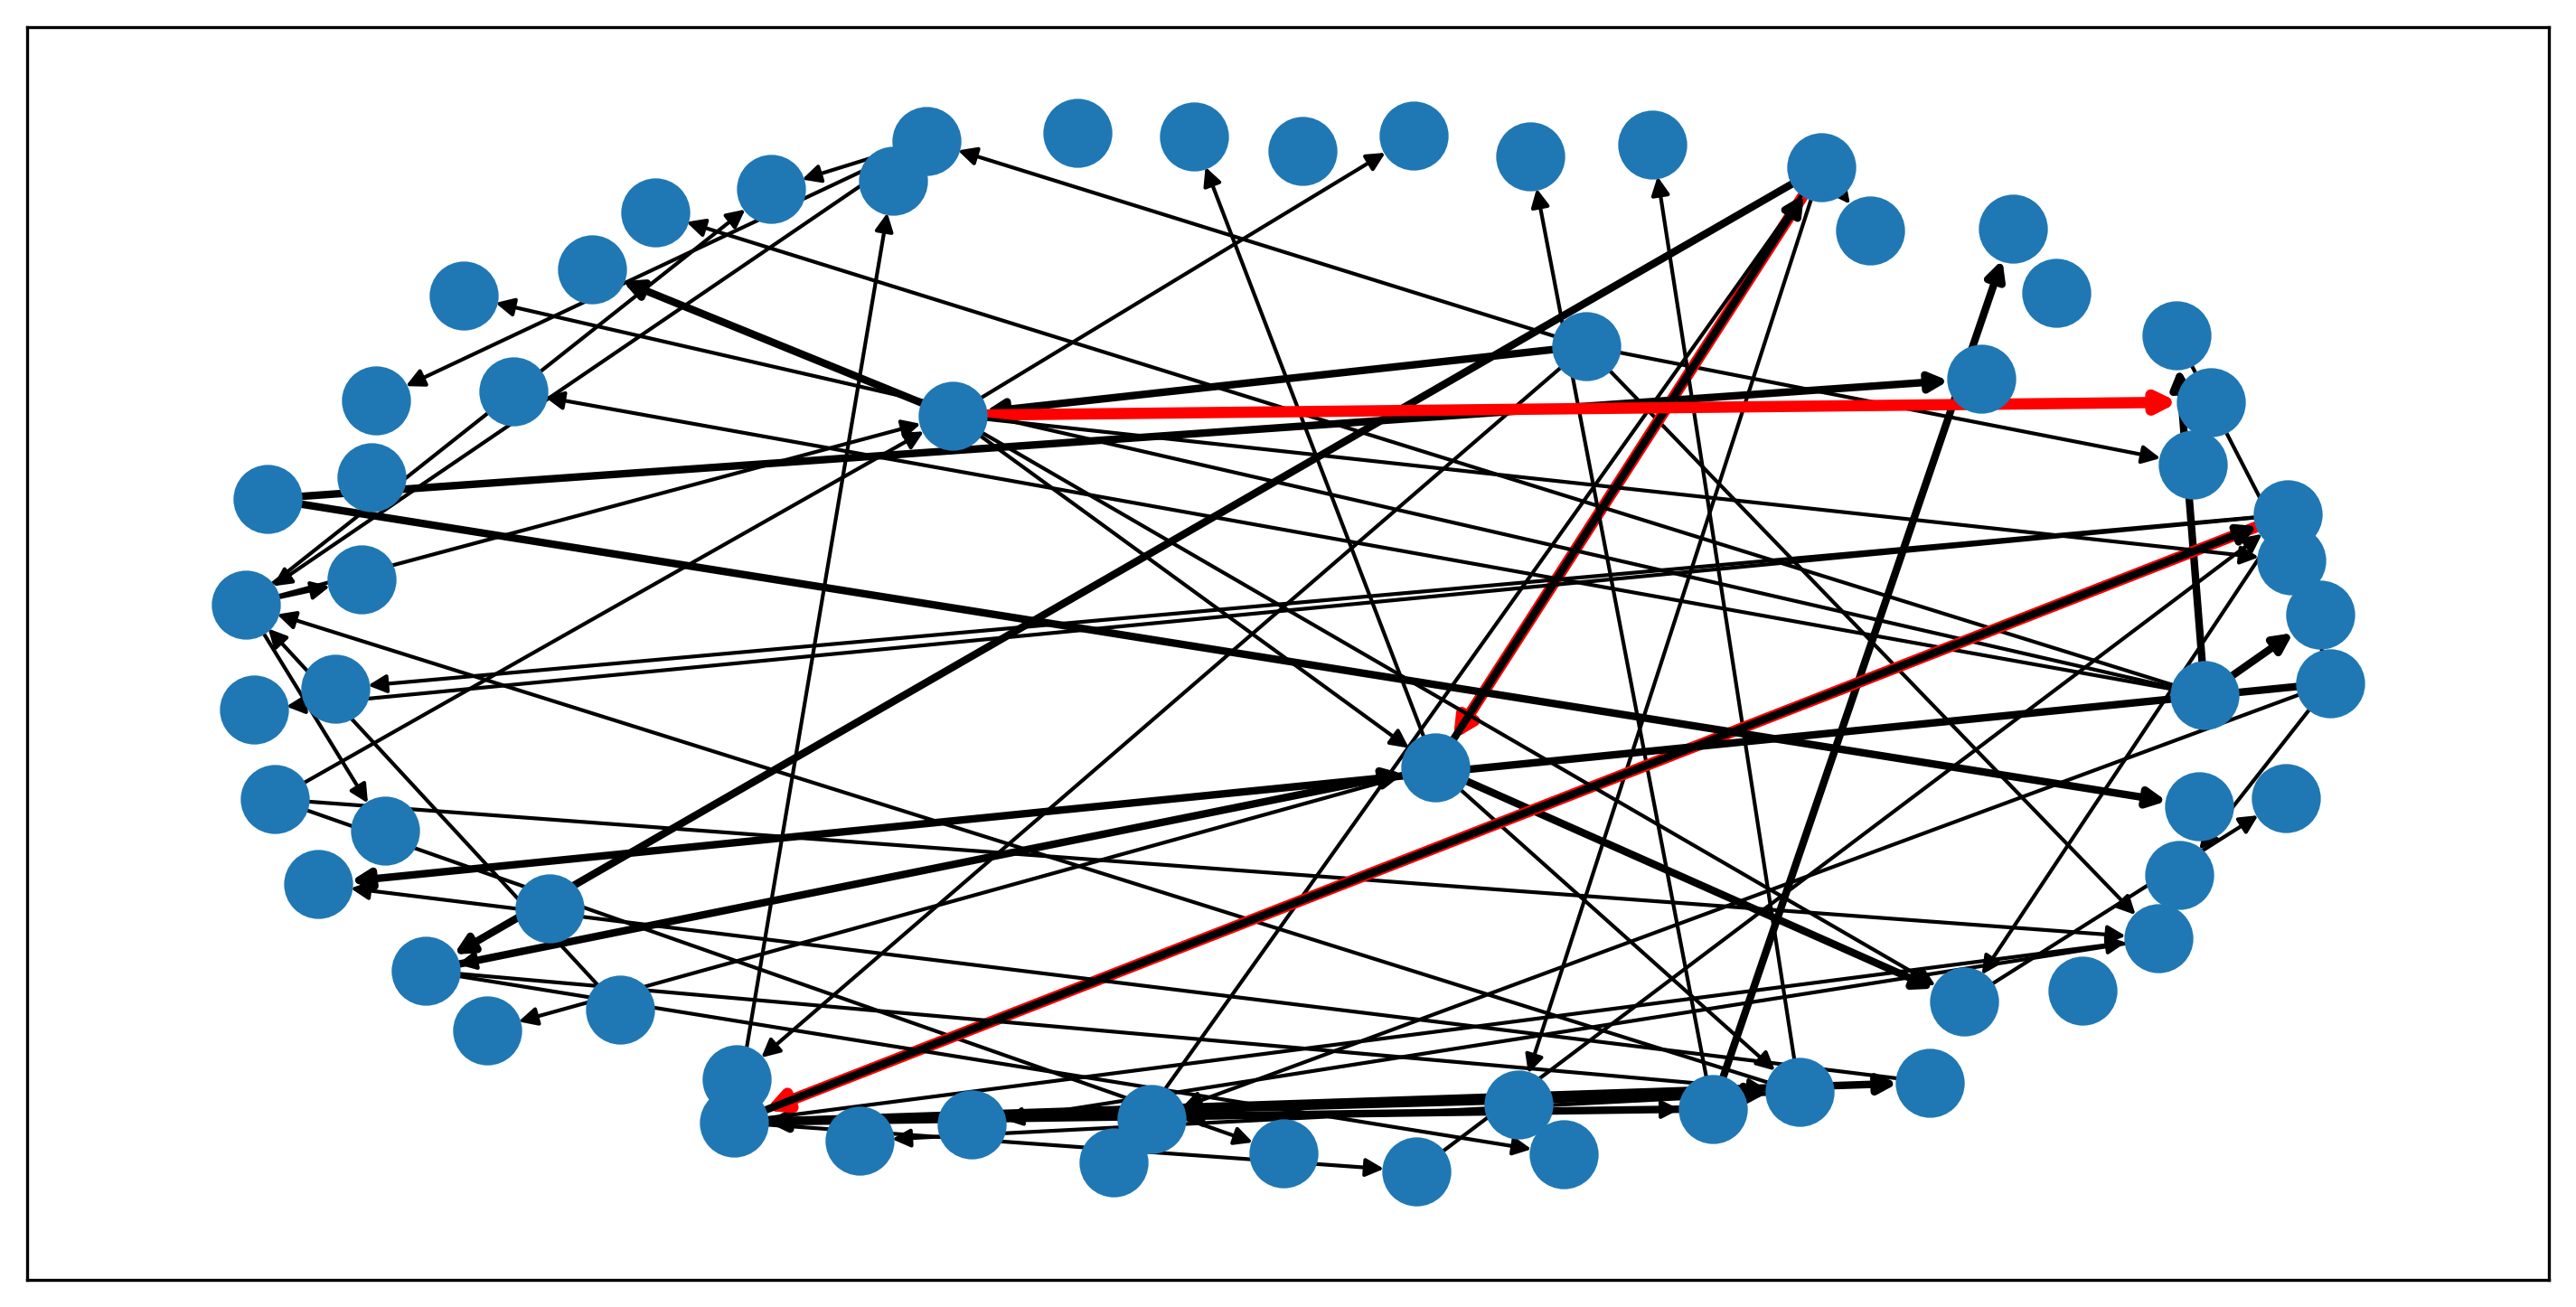

In [235]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6), dpi=300)
pos = nx.spring_layout(grafo_defesas, k=2, seed = 1931)

# nx.draw(grafo_defesas, with_labels=False, font_weight='bold', pos=pos)
nx.draw_networkx_nodes(grafo_defesas, pos=pos)
nx.draw_networkx_edges(grafo_defesas, pos=pos, width=edge_widths, edge_color=edge_colors)
plt.show()